# Performance Benchmarking: Multiferroic Simulation Framework

This notebook evaluates the performance and scaling characteristics of the **Multiferroic** simulation framework. We measure the throughput (Monte Carlo steps per second) and the computational cost of physical analysis functions (energy, magnetization, correlation functions, and vorticity) across different lattice sizes and models.

## Objectives
1. **Throughput Analysis**: Measure how many Monte Carlo sweeps per second each model can perform as a function of system size $N = L^2$.
2. **Analysis Overhead**: Quantify the cost of thermodynamic measurements and correlation function calculations.
3. **Scaling Behavior**: Verify the expected $O(N)$ or $O(N \log N)$ scaling for various operations.

In [2]:
import time

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from models.clock_model import ClockSimulation
from models.ising_model import IsingSimulation
from models.xy_model import XYSimulation

%matplotlib inline
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.dpi'] = 100

## Benchmark Configuration

We define a helper function to measure throughput and analysis times. Note that the first call to any Numba-jitted function will include compilation time; we perform a 'warm-up' step to ensure we measure execution speed.

In [3]:
def measure_performance(sim, sweeps=100, analysis_iters=20):
    """Measure sweeps/sec and analysis times for a simulation instance."""
    # Warm-up (triggers Numba JIT compilation)
    sim.step()
    sim._get_energy()
    sim._calculate_correlation_function()
    if hasattr(sim, '_calculate_vorticity'):
        sim._calculate_vorticity()

    # 1. Sweep speed (Throughput)
    start = time.perf_counter()
    for _ in range(sweeps):
        sim.step()
    sweep_duration = time.perf_counter() - start
    sps = sweeps / sweep_duration

    # 2. Thermodynamic measurements (Energy + Magnetization)
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._get_energy()
        sim._get_magnetization()
    thermo_ms = (time.perf_counter() - start) / analysis_iters * 1000

    # 3. Correlation function G(r) (FFT-based)
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._calculate_correlation_function()
    corr_ms = (time.perf_counter() - start) / analysis_iters * 1000

    # 4. Vorticity (Topological defects)
    vort_ms = 0.0
    if hasattr(sim, '_calculate_vorticity'):
        start = time.perf_counter()
        for _ in range(analysis_iters):
            sim._calculate_vorticity()
        vort_ms = (time.perf_counter() - start) / analysis_iters * 1000

    return {'sps': sps, 'thermo_ms': thermo_ms, 'corr_ms': corr_ms, 'vort_ms': vort_ms}

## Execution

We run the benchmark across a range of lattice sizes for the Ising, XY, and Clock models.

In [4]:
sizes = [32, 64, 128, 256, 512]
model_configs = [
    ('Ising (Checkerboard)', lambda L: IsingSimulation(L, 2.269, update='checkerboard')),
    ('Ising (Random)', lambda L: IsingSimulation(L, 2.269, update='random')),
    ('XY (Checkerboard)', lambda L: XYSimulation(L, 0.89, update='checkerboard')),
    ('XY (Random)', lambda L: XYSimulation(L, 0.89, update='random')),
    ('Clock (Checkerboard)', lambda L: ClockSimulation(L, 0.5, q=6, update='checkerboard')),
    ('Clock (Random)', lambda L: ClockSimulation(L, 0.5, q=6, update='random')),
]

results = {name: {} for name, _ in model_configs}

for L in tqdm(sizes, desc="Lattice Sizes"):
    for name, constructor in model_configs:
        sim = constructor(L)
        # Use fewer sweeps for larger lattices to keep benchmark time reasonable
        n_sweeps = 200 if L <= 128 else 50
        metrics = measure_performance(sim, sweeps=n_sweeps)
        results[name][L] = metrics

Lattice Sizes:   0%|          | 0/5 [00:00<?, ?it/s]

## Visualization

### 1. Throughput (Sweeps / Second)
Higher is better. This measures how quickly the system evolves through phase space.

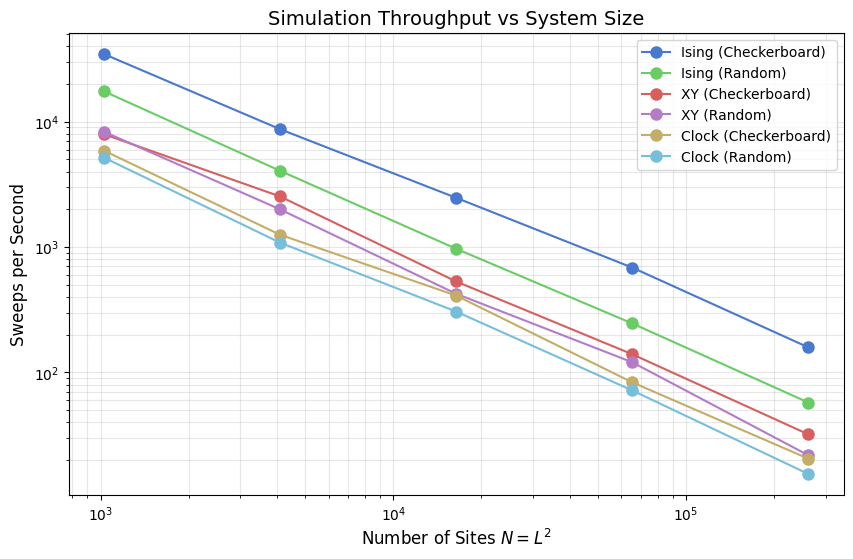

In [5]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    sps_vals = [results[name][L]['sps'] for L in L_vals]
    plt.loglog(N_vals, sps_vals, 'o-', label=name, markersize=8)

plt.title('Simulation Throughput vs System Size', fontsize=14)
plt.xlabel('Number of Sites $N = L^2$', fontsize=12)
plt.ylabel('Sweeps per Second', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

### 2. Analysis Costs
Lower is better. We compare the cost of standard thermodynamic measurements vs. the FFT-based correlation function.

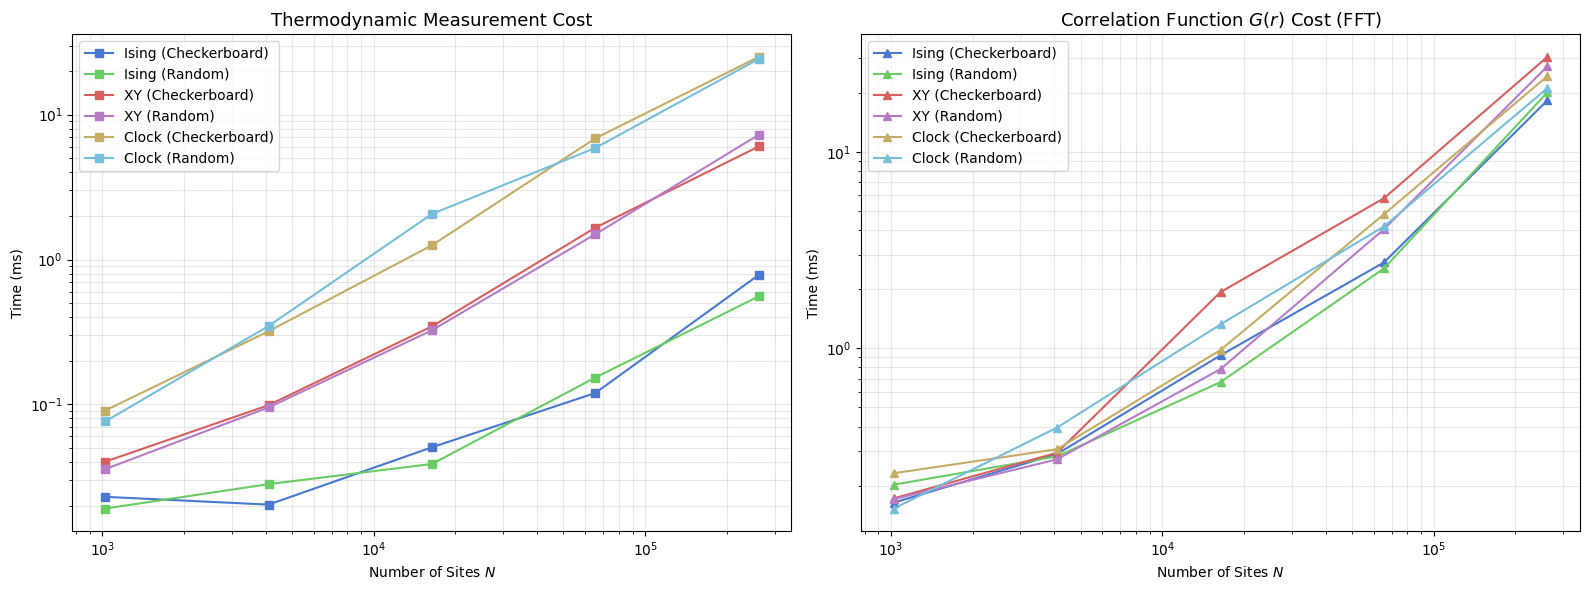

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]

    # Thermo Cost
    thermo_vals = [results[name][L]['thermo_ms'] for L in L_vals]
    ax1.loglog(N_vals, thermo_vals, 's-', label=name)

    # Correlation Cost
    corr_vals = [results[name][L]['corr_ms'] for L in L_vals]
    ax2.loglog(N_vals, corr_vals, '^-', label=name)

ax1.set_title('Thermodynamic Measurement Cost', fontsize=13)
ax1.set_xlabel('Number of Sites $N$')
ax1.set_ylabel('Time (ms)')
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.set_title('Correlation Function $G(r)$ Cost (FFT)', fontsize=13)
ax2.set_xlabel('Number of Sites $N$')
ax2.set_ylabel('Time (ms)')
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

### 3. Analysis Overhead Ratio
This ratio (Total Analysis Time / Sweep Time) indicates how much slower the simulation becomes if we perform a full measurement suite at every step. A ratio $< 1$ means measurements are faster than the physics update itself.

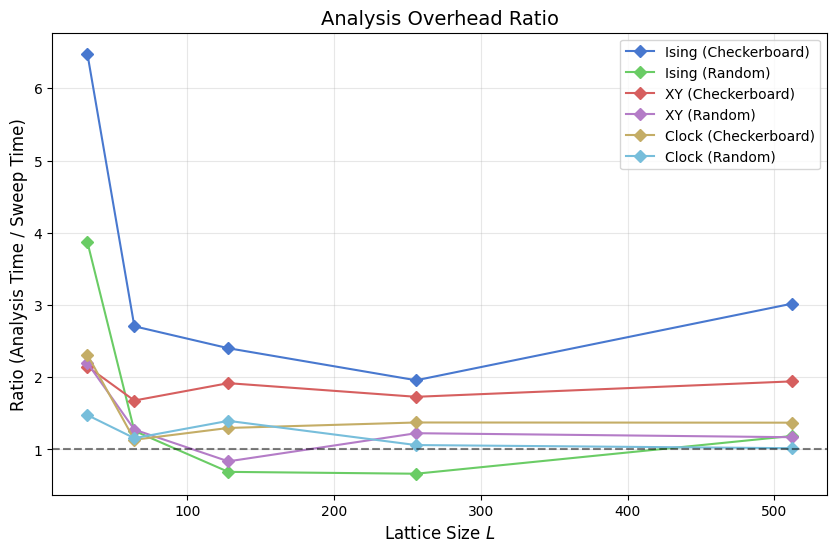

In [7]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    ratios = []
    for L in L_vals:
        m = results[name][L]
        sweep_ms = (1.0 / m['sps']) * 1000
        total_analysis_ms = m['thermo_ms'] + m['corr_ms'] + m['vort_ms']
        ratios.append(total_analysis_ms / sweep_ms)

    plt.plot(L_vals, ratios, 'D-', label=name)

plt.title('Analysis Overhead Ratio', fontsize=14)
plt.xlabel('Lattice Size $L$', fontsize=12)
plt.ylabel('Ratio (Analysis Time / Sweep Time)', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary Table
Finally, we display the raw numbers for the largest lattice size tested.

In [8]:
L_max = sizes[-1]
print(f"Performance metrics for L = {L_max} (N = {L_max*L_max})")
print("-" * 80)
print(f"{'Model':<25} | {'Sweeps/s':>12} | {'Thermo (ms)':>12} | {'G(r) (ms)':>12}")
print("-" * 80)

for name in results:
    m = results[name][L_max]
    print(f"{name:<25} | {m['sps']:>12.1f} | {m['thermo_ms']:>12.3f} | {m['corr_ms']:>12.3f}")

Performance metrics for L = 512 (N = 262144)
--------------------------------------------------------------------------------
Model                     |     Sweeps/s |  Thermo (ms) |    G(r) (ms)
--------------------------------------------------------------------------------
Ising (Checkerboard)      |        158.4 |        0.783 |       18.275
Ising (Random)            |         57.5 |        0.557 |       20.081
XY (Checkerboard)         |         32.1 |        6.034 |       30.434
XY (Random)               |         21.8 |        7.267 |       27.247
Clock (Checkerboard)      |         20.5 |       25.046 |       24.282
Clock (Random)            |         15.5 |       24.250 |       21.079
